# **Theory**
## Core Equations Used in this Demo (From Bellman to MAPPO)

Below are the main mathematical foundations behind the PPO-based multi-agent training used in this notebook.

---

### 1. Markov Decision Process (MDP)

An MDP is defined as:

$$
(S, A, P, R, \gamma)
$$

Where:

- $S$ = state space  
- $A$ = action space  
- $P(s' \mid s,a)$ = transition probability  
- $R(s,a)$ = reward function  
- $\gamma \in [0,1]$ = discount factor  

This notebook operates under a **multi-agent stochastic game**.

---

### 2. Bellman Expectation Equation

$$
V^\pi(s) = \mathbb{E}_{a \sim \pi}
\left[ R(s,a) + \gamma V^\pi(s') \right]
$$

"The value of state $s$ equals expected immediate reward plus discounted future value."

---

### 3. Q-Function Bellman Equation

$$
Q^\pi(s,a) =
R(s,a) + \gamma \mathbb{E}_{s'}[V^\pi(s')]
$$

Expected return starting from state–action pair.

---

### 4. Advantage Function

$$
A^\pi(s,a) = Q^\pi(s,a) - V^\pi(s)
$$

Measures how much better an action is compared to average behavior.

---

### 5. Generalized Advantage Estimation (GAE)

TD error:

$$
\delta_t =
r_t + \gamma V(s_{t+1}) - V(s_t)
$$

GAE:

$$
A_t^{GAE(\lambda)} =
\sum_{l=0}^{\infty}
(\gamma \lambda)^l \delta_{t+l}
$$

Reduces variance in policy gradients.

---

### 6. Policy Gradient

$$
\nabla_\theta J(\theta) =
\mathbb{E}
\left[
\nabla_\theta \log \pi_\theta(a|s)
A^\pi(s,a)
\right]
$$

Increase probability of good actions.

---

### 7. PPO Clipped Objective

Probability ratio:

$$
r_t(\theta) =
\frac{\pi_\theta(a_t|s_t)}
{\pi_{\theta_{old}}(a_t|s_t)}
$$

Clipped objective:

$$
L^{CLIP}(\theta) =
\mathbb{E}
\left[
\min
\left(
r_t A_t,
\text{clip}(r_t,1-\epsilon,1+\epsilon)A_t
\right)
\right]
$$

Prevents large unstable updates.

---

### 8. Value Loss

$$
L^{value} =
\mathbb{E}
\left[
(V_\theta(s_t)-R_t)^2
\right]
$$

Trains critic network.


---

### 9. MAPPO (Multi-Agent PPO)

Joint policy factorization:

$$
\pi(a_1,...,a_N|o_1,...,o_N)
=
\prod_{i=1}^{N}
\pi_i(a_i|o_i)
$$

MAPPO objective:

$$
L^{MAPPO} =
\sum_{i=1}^{N}
\mathbb{E}
\left[
\min(
r_{t,i}A_{t,i},
\text{clip}(r_{t,i},1-\epsilon,1+\epsilon)A_{t,i}
)
\right]
$$

Extends PPO to cooperative multi-agent learning.

---

#### Flow

Bellman → Value → Advantage → Policy Gradient → PPO → MAPPO

### Why so many steps?
This mathematical flow begins with the Markov Decision Process (MDP) because reinforcement learning problems must first be formally defined in terms of states, actions, transitions, rewards, and discounting. The Bellman equation is introduced next because it provides the recursive definition of value — it tells us how future rewards accumulate and therefore defines what "good" behavior means. From the value function, we derive the Q-function and then the advantage function, which is required for, how much better is a particular action compared to the average behavior at that state?

Since directly optimizing for value is difficult, we use the policy gradient theorem, which tells us how to adjust policy parameters to increase the probability of advantageous actions. But naive policy gradients can be unstable, which is why PPO introduces a clipped objective — to prevent excessively large updates and ensure stable learning. A value loss is added to train the critic that estimates returns, reducing variance in updates. Finally, we extend PPO to the multi-agent setting as MAPPO, where each agent optimizes its clipped objective while coordinating through shared experience, enabling decentralized execution with stable cooperative learning.




# Multi-Agent Reinforcement Learning with PPO in VMAS

## Problem Definition

This notebook solves a **cooperative multi-agent reinforcement learning (MARL)** problem in a continuous control environment using the VMAS simulator. In the navigation scenario, multiple agents operate in a shared environment and must learn policies that maximize cumulative rewards over fixed-length episodes. Each agent acts based on its own local observation (decentralized execution), while learning is performed jointly. The challenge is to achieve stable and coordinated behavior among agents in a continuous action space.

---

## Objectives

The key objectives of this notebook are:

- Implement **Proximal Policy Optimization (PPO)** for multi-agent learning.
- Train decentralized policies with shared parameters across agents.
- Efficiently collect experience using vectorized parallel environments.
- Stabilize learning using clipped PPO loss, GAE, entropy regularization, and gradient clipping.
- Evaluate performance through cumulative episode rewards.

---

## Methodology

The training pipeline consists of:

### 1. Environment Setup
- VMAS multi-agent navigation scenario.
- Parallelized environment rollout for efficient data collection.
- Reward transformation to compute episode-level cumulative rewards.

### 2. Policy Network
- `MultiAgentMLP` architecture.
- Decentralized policy (each agent acts on local observations).
- Shared parameters across agents.
- Gaussian action distribution using `TanhNormal`.

### 3. Training Procedure
- On-policy data collection using `SyncDataCollector`.
- PPO optimization with clipped surrogate objective.
- Generalized Advantage Estimation (GAE) for stable value targets.
- Multiple epochs and mini-batch updates per iteration.
- Gradient norm clipping and entropy bonus for stable exploration.

---

## Results

The notebook demonstrates stable multi-agent learning, improvement in cumulative episode rewards over training iterations, and effective coordination among agents despite decentralized execution. PPO with shared-parameter policies provides a scalable and robust framework for cooperative multi-agent control tasks.

This notebook trains multiple agents using MAPPO.
Agents learn to cooperate in a navigation task.

We will:
- Create the environment
- Build policy and value networks
- Train using PPO
- Visualize learning


## What different acronyms mean?

### PPO – Proximal Policy Optimization  
**Function:** A policy-gradient reinforcement learning algorithm that updates policies using a clipped surrogate objective to prevent large policy shifts.  
**Motivation:** Provides stable and reliable policy updates in continuous control tasks, making it well-suited for multi-agent training.

---

### MARL – Multi-Agent Reinforcement Learning  
**Function:** A reinforcement learning framework where multiple agents learn simultaneously in a shared environment.  
**Motivation:** Required because the navigation task involves multiple interacting agents that must coordinate behavior.

---

### VMAS – Vectorized Multi-Agent Simulator  
**Function:** A GPU-accelerated simulator designed for multi-agent reinforcement learning research.  
**Motivation:** Enables efficient parallel simulation of multiple environments for faster data collection and training.

---

### MLP – Multi-Layer Perceptron  
**Function:** A feedforward neural network used to approximate policy and value functions.  
**Motivation:** Provides flexible nonlinear function approximation for mapping observations to action distributions.

---

### GAE – Generalized Advantage Estimation  
**Function:** Computes advantage values using a weighted combination of temporal-difference errors.  
**Motivation:** Reduces variance while controlling bias, leading to more stable PPO updates.

---

### GPU – Graphics Processing Unit  
**Function:** Hardware accelerator for parallel tensor computations.  
**Motivation:** Speeds up neural network training and allows VMAS to simulate environments efficiently.

---

### CPU – Central Processing Unit  
**Function:** General-purpose processor used for computation when GPU is unavailable or unsafe (e.g., fork mode).  
**Motivation:** Provides fallback execution to ensure compatibility and stability.

---

### TD – Temporal Difference  
**Function:** Learning approach that updates value estimates using bootstrapped future rewards.  
**Motivation:** Used implicitly in PPO via value estimation and GAE.

---

### LR – Learning Rate  
**Function:** Controls the step size of gradient-based optimization.  
**Motivation:** Determines how quickly the neural network parameters are updated during training.

---

### KL – Kullback–Leibler Divergence  
**Function:** Measures the difference between two probability distributions.  
**Motivation:** PPO indirectly controls policy change (similar to KL constraints) using clipping to maintain stable learning.

---

### RL – Reinforcement Learning  
**Function:** Learning paradigm where agents learn to maximize cumulative reward through interaction.  
**Motivation:** Core framework for training autonomous agents in dynamic environments.

---

### MDP – Markov Decision Process  
**Function:** Mathematical framework defining states, actions, rewards, and transitions.  
**Motivation:** Forms the theoretical foundation for PPO and policy/value learning in this notebook.

## Environment

We use a multi-agent navigation environment.
Each agent:
- Observes its own state
- Takes continuous actions
- Receives reward for cooperation


In [1]:
!apt-get -y update
!apt-get -y install xvfb libglu1-mesa libgl1-mesa-glx mesa-utils python3-opengl

!pip3 install torchrl
!pip3 install vmas
!pip3 install tqdm

Hit:1 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:2 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:3 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:4 https://cli.github.com/packages stable InRelease [3,917 B]
Get:5 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:6 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:7 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:9 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [85.0 kB]
Get:10 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease [24.6 kB]
Get:11 https://cli.github.com/packages stable/main amd64 Packages [357 B]
Get:12 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [2,910 kB]
Get:13 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [9,773 kB]
Get:14 http://

In [2]:
# Torch
import torch
# Core PyTorch library: tensors, autograd, neural networks, optimizers, GPU support

# Tensordict modules
from tensordict.nn import set_composite_lp_aggregate, TensorDictModule
# set_composite_lp_aggregate: sets how log-probabilities are aggregated
# TensorDictModule: wraps a PyTorch module to read/write inputs/outputs from a TensorDict (structured dict of tensors)

from tensordict.nn.distributions import NormalParamExtractor
# Extracts mean and std parameters from network output to define a Normal distribution

from torch import multiprocessing
# PyTorch multiprocessing utilities for parallel data collection or training

# Data collection
from torchrl.collectors import SyncDataCollector
# Collects rollouts synchronously from environment(s) using the current policy

from torchrl.data.replay_buffers import ReplayBuffer
# Stores collected transitions for sampling during training

from torchrl.data.replay_buffers.samplers import SamplerWithoutReplacement
# Samples mini-batches from replay buffer without repeating samples in an epoch

from torchrl.data.replay_buffers.storages import LazyTensorStorage
# Memory-efficient storage backend for replay buffer using lazy tensor allocation

# Env
from torchrl.envs import RewardSum, TransformedEnv
# RewardSum: transformation to accumulate rewards over an episode
# TransformedEnv: wrapper to apply transformations (e.g., normalization, reward shaping) to an environment

from torchrl.envs.libs.vmas import VmasEnv
# Multi-agent VMAS (Vectorized Multi-Agent Simulator) environment for MARL experiments

from torchrl.envs.utils import check_env_specs
# Utility to verify that environment input/output specs match expectations

# Multi-agent network
from torchrl.modules import MultiAgentMLP, ProbabilisticActor, TanhNormal
# MultiAgentMLP: shared or centralized MLP for multiple agents
# ProbabilisticActor: wraps policy network to output a probability distribution over actions
# TanhNormal: squashed Normal distribution (via tanh) for bounded continuous actions

# Loss
from torchrl.objectives import ClipPPOLoss, ValueEstimators
# ClipPPOLoss: PPO clipped surrogate objective for stable policy updates
# ValueEstimators: utilities for computing value targets (e.g., GAE, TD)

# Utils
torch.manual_seed(0)
# Sets random seed for reproducibility

from matplotlib import pyplot as plt
# Plotting library for visualization

from tqdm import tqdm
# Progress bar utility for loops (e.g., training iterations)

## Policy Network (Actor)

The policy maps observations to actions.
It outputs mean and standard deviation.
Actions are sampled from a Tanh-Normal distribution.

This block sets up the computational device, data collection scale, training hyperparameters, and PPO-specific settings for the experiment. First, it checks whether multiprocessing is using the "fork" method (which can conflict with CUDA), and accordingly selects either the GPU (if available and safe) or the CPU as the training device; the same device is used for the VMAS multi-agent simulator. The sampling section defines how much experience is collected: 6,000 environment steps per iteration over 5 iterations, giving the total number of interaction frames. The training section controls optimization behavior—how many times the collected data is reused (num_epochs), the mini-batch size, the learning rate, and gradient clipping to ensure stable updates. The PPO section specifies the clipped surrogate objective parameters, including the clipping threshold (clip_epsilon), discount factor (gamma), GAE parameter (lambda) for bias–variance tradeoff, and entropy regularization to encourage exploration. Finally, log-probability aggregation is disabled to allow finer control over how action log-probabilities are handled, which is particularly useful in multi-agent or composite action settings.


In [21]:
# Devices
is_fork = multiprocessing.get_start_method() == "fork"
device = (
    torch.device(0)
    if torch.cuda.is_available() and not is_fork
    else torch.device("cpu")
)
vmas_device = device  # The device where the simulator is run (VMAS can run on GPU)

# Sampling
frames_per_batch = 6_000  # Number of team frames collected per training iteration
n_iters = 5  # Number of sampling and training iterations
total_frames = frames_per_batch * n_iters

# Training
num_epochs = 30  # Number of optimization steps per training iteration
minibatch_size = 400  # Size of the mini-batches in each optimization step
lr = 3e-4  # Learning rate
max_grad_norm = 1.0  # Maximum norm for the gradients

# PPO
clip_epsilon = 0.2  # clip value for PPO loss
gamma = 0.99  # discount factor
lmbda = 0.9  # lambda for generalised advantage estimation
entropy_eps = 1e-4  # coefficient of the entropy term in the PPO loss

# disable log-prob aggregation
set_composite_lp_aggregate(False).set()

## Value Network (Critic)

The critic estimates expected future reward.
We use a centralized critic during training.
Execution remains decentralized.

This block configures and creates the multi-agent simulation environment used for training.

It first defines the episode length (max_steps = 100), meaning each environment runs for 100 timesteps before terminating. Then it computes how many parallel (vectorized) environments to run (num_vmas_envs) by dividing the total frames per batch by the episode length — this ensures that one full batch is collected by running multiple environments in parallel for exactly one episode each. The scenario "navigation" specifies the task (typically cooperative navigation in VMAS), and n_agents = 4 sets the number of agents in each environment.

Finally, VmasEnv(...) initializes a vectorized multi-agent simulator where:

- Multiple environments run in parallel (num_envs),

- Each environment contains 4 agents,

- Actions are continuous,

- Episodes last up to 100 steps,

- The simulation runs on the chosen device (CPU/GPU).

In short, this block builds a parallelized 4-agent navigation world where agents will learn via PPO by interacting with the environment efficiently in batches.


In [4]:
max_steps = 100  # Episode steps before done
num_vmas_envs = (
    frames_per_batch // max_steps
)  # Number of vectorized envs. frames_per_batch should be divisible by this number
scenario_name = "navigation"
n_agents = 4

env = VmasEnv(
    scenario=scenario_name,
    num_envs=num_vmas_envs,
    continuous_actions=True,  # VMAS supports both continuous and discrete actions
    max_steps=max_steps,
    device=vmas_device,
    # Scenario kwargs
    n_agents=n_agents,  # These are custom kwargs that change for each VMAS scenario, see the VMAS repo to know more.
)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## PPO Loss

PPO updates the policy carefully using clipping.
This prevents unstable updates.
Loss includes:
- Policy loss
- Value loss
- Entropy bonus


In [5]:
print("action_spec:", env.full_action_spec)
print("reward_spec:", env.full_reward_spec)
print("done_spec:", env.full_done_spec)
print("observation_spec:", env.observation_spec)

action_spec: Composite(
    agents: Composite(
        action: BoundedContinuous(
            shape=torch.Size([60, 4, 2]),
            space=ContinuousBox(
                low=Tensor(shape=torch.Size([60, 4, 2]), device=cpu, dtype=torch.float32, contiguous=True),
                high=Tensor(shape=torch.Size([60, 4, 2]), device=cpu, dtype=torch.float32, contiguous=True)),
            device=cpu,
            dtype=torch.float32,
            domain=continuous),
        device=cpu,
        shape=torch.Size([60, 4]),
        data_cls=None),
    device=cpu,
    shape=torch.Size([60]),
    data_cls=None)
reward_spec: Composite(
    agents: Composite(
        reward: UnboundedContinuous(
            shape=torch.Size([60, 4, 1]),
            space=ContinuousBox(
                low=Tensor(shape=torch.Size([60, 4, 1]), device=cpu, dtype=torch.float32, contiguous=True),
                high=Tensor(shape=torch.Size([60, 4, 1]), device=cpu, dtype=torch.float32, contiguous=True)),
            devic

## Advantage Estimation

We use GAE (Generalized Advantage Estimation).
Advantage tells us how good an action was.


In [6]:
print("action_keys:", env.action_keys)
print("reward_keys:", env.reward_keys)
print("done_keys:", env.done_keys)

action_keys: [('agents', 'action')]
reward_keys: [('agents', 'reward')]
done_keys: ['done', 'terminated']


## Training Loop

Each iteration:
1. Collect data
2. Compute advantages
3. Update networks
4. Repeat


*TransformedEnv* is basically a wrapper that lets you modify or augment the environment's inputs/outputs without changing the core simulator.

Inside it, *RewardSum(...)* takes the per-step reward (env.reward_key) and keeps a running sum across the episode. It stores this cumulative reward in a new key:
("agents", "episode_reward").

So instead of only having immediate rewards at each timestep, you now also get the total episode reward per agent, which is very useful for:

- Logging performance,

- Plotting training curves,

- Evaluating convergence.

Basically, this code adds automatic episode-level reward tracking on top of multi-agent environment.

In [7]:
env = TransformedEnv(
    env,
    RewardSum(in_keys=[env.reward_key], out_keys=[("agents", "episode_reward")]),
)

## Summary

This is Multi-Agent PPO (MAPPO).
Centralized training.
Decentralized execution.
Stable and effective for cooperation.


In [8]:
check_env_specs(env)

2026-02-24 09:16:56,037 [torchrl][INFO]    check_env_specs succeeded! [END]


## Summary

This is Multi-Agent PPO (MAPPO).
Centralized training.
Decentralized execution.
Stable and effective for cooperation.


In [9]:
n_rollout_steps = 5
rollout = env.rollout(n_rollout_steps)
print("rollout of three steps:", rollout)
print("Shape of the rollout TensorDict:", rollout.batch_size)

rollout of three steps: TensorDict(
    fields={
        agents: TensorDict(
            fields={
                action: Tensor(shape=torch.Size([60, 5, 4, 2]), device=cpu, dtype=torch.float32, is_shared=False),
                episode_reward: Tensor(shape=torch.Size([60, 5, 4, 1]), device=cpu, dtype=torch.float32, is_shared=False),
                info: TensorDict(
                    fields={
                        agent_collisions: Tensor(shape=torch.Size([60, 5, 4, 1]), device=cpu, dtype=torch.float32, is_shared=False),
                        final_rew: Tensor(shape=torch.Size([60, 5, 4, 1]), device=cpu, dtype=torch.float32, is_shared=False),
                        pos_rew: Tensor(shape=torch.Size([60, 5, 4, 1]), device=cpu, dtype=torch.float32, is_shared=False)},
                    batch_size=torch.Size([60, 5, 4]),
                    device=cpu,
                    is_shared=False),
                observation: Tensor(shape=torch.Size([60, 5, 4, 18]), device=cpu, dtype=torc

## Summary

This is Multi-Agent PPO (MAPPO).
Centralized training.
Decentralized execution.
Stable and effective for cooperation.

This block defines the policy network for all agents.

*share_parameters_policy = True* means all agents use the same neural network weights (parameter sharing). This is common in cooperative MARL because agents are often symmetric — it improves sample efficiency and stability.

The core network is a MultiAgentMLP. It:

Takes each agent's own observation as input (*n_agent_inputs*),

Outputs action parameters per agent,

Is decentralised (*centralised=False*), meaning each agent acts only from its own observation (no global state),

Produces outputs for all agents in parallel,

Uses 2 hidden layers (*depth=2*) with 256 units each and Tanh activation.

The output size is 2*action_dim because PPO uses a Gaussian policy for continuous control. For each action dimension, the network must predict:

- A mean (loc)

- A standard deviation (scale)

The NormalParamExtractor() then splits the final layer into those two components (mean and positive std), preparing them to define a Normal distribution.


In [10]:
share_parameters_policy = True

policy_net = torch.nn.Sequential(
    MultiAgentMLP(
        n_agent_inputs=env.observation_spec["agents", "observation"].shape[
            -1
        ],  # n_obs_per_agent
        n_agent_outputs=2
        * env.full_action_spec[env.action_key].shape[-1],  # 2 * n_actions_per_agents
        n_agents=env.n_agents,
        centralised=False,  # the policies are decentralised (ie each agent will act from its observation)
        share_params=share_parameters_policy,
        device=device,
        depth=2,
        num_cells=256,
        activation_class=torch.nn.Tanh,
    ),
    NormalParamExtractor(),  # this will just separate the last dimension into two outputs: a loc and a non-negative scale
)

## Summary

This is Multi-Agent PPO (MAPPO).
Centralized training.
Decentralized execution.
Stable and effective for cooperation.


In [11]:
policy_module = TensorDictModule(
    policy_net,
    in_keys=[("agents", "observation")],
    out_keys=[("agents", "loc"), ("agents", "scale")],
)

## Summary

This is Multi-Agent PPO (MAPPO).
Centralized training.
Decentralized execution.
Stable and effective for cooperation.


In [12]:
policy = ProbabilisticActor(
    module=policy_module,
    spec=env.action_spec_unbatched,
    in_keys=[("agents", "loc"), ("agents", "scale")],
    out_keys=[env.action_key],
    distribution_class=TanhNormal,
    distribution_kwargs={
        "low": env.full_action_spec_unbatched[env.action_key].space.low,
        "high": env.full_action_spec_unbatched[env.action_key].space.high,
    },
    return_log_prob=True,
)  # we'll need the log-prob for the PPO loss

## Summary

This is Multi-Agent PPO (MAPPO).
Centralized training.
Decentralized execution.
Stable and effective for cooperation.


In [13]:
share_parameters_critic = True
mappo = True  # IPPO if False

critic_net = MultiAgentMLP(
    n_agent_inputs=env.observation_spec["agents", "observation"].shape[-1],
    n_agent_outputs=1,  # 1 value per agent
    n_agents=env.n_agents,
    centralised=mappo,
    share_params=share_parameters_critic,
    device=device,
    depth=2,
    num_cells=256,
    activation_class=torch.nn.Tanh,
)

critic = TensorDictModule(
    module=critic_net,
    in_keys=[("agents", "observation")],
    out_keys=[("agents", "state_value")],
)

## Summary

This is Multi-Agent PPO (MAPPO).
Centralized training.
Decentralized execution.
Stable and effective for cooperation.


In [14]:
print("Running policy:", policy(env.reset()))
print("Running value:", critic(env.reset()))

Running policy: TensorDict(
    fields={
        agents: TensorDict(
            fields={
                action: Tensor(shape=torch.Size([60, 4, 2]), device=cpu, dtype=torch.float32, is_shared=False),
                action_log_prob: Tensor(shape=torch.Size([60, 4]), device=cpu, dtype=torch.float32, is_shared=False),
                episode_reward: Tensor(shape=torch.Size([60, 4, 1]), device=cpu, dtype=torch.float32, is_shared=False),
                info: TensorDict(
                    fields={
                        agent_collisions: Tensor(shape=torch.Size([60, 4, 1]), device=cpu, dtype=torch.float32, is_shared=False),
                        final_rew: Tensor(shape=torch.Size([60, 4, 1]), device=cpu, dtype=torch.float32, is_shared=False),
                        pos_rew: Tensor(shape=torch.Size([60, 4, 1]), device=cpu, dtype=torch.float32, is_shared=False)},
                    batch_size=torch.Size([60, 4]),
                    device=cpu,
                    is_shared=False),


## Summary

This is Multi-Agent PPO (MAPPO).
Centralized training.
Decentralized execution.
Stable and effective for cooperation.


In [15]:
collector = SyncDataCollector(
    env,
    policy,
    device=vmas_device,
    storing_device=device,
    frames_per_batch=frames_per_batch,
    total_frames=total_frames,
)

/usr/local/lib/python3.12/dist-packages/torchrl/collectors/_base.py:1045: DeprecationWarning: SyncDataCollector has been deprecated and will be removed in v0.13. Please use Collector instead.
  warnings.warn(


## Summary

This is Multi-Agent PPO (MAPPO).
Centralized training.
Decentralized execution.
Stable and effective for cooperation.


In [16]:
replay_buffer = ReplayBuffer(
    storage=LazyTensorStorage(
        frames_per_batch, device=device
    ),  # We store the frames_per_batch collected at each iteration
    sampler=SamplerWithoutReplacement(),
    batch_size=minibatch_size,  # We will sample minibatches of this size
)

## Summary

This is Multi-Agent PPO (MAPPO).
Centralized training.
Decentralized execution.
Stable and effective for cooperation.


In [17]:
loss_module = ClipPPOLoss(
    actor_network=policy,
    critic_network=critic,
    clip_epsilon=clip_epsilon,
    entropy_coeff=entropy_eps,
    normalize_advantage=False,  # Important to avoid normalizing across the agent dimension
)
loss_module.set_keys(  # We have to tell the loss where to find the keys
    reward=env.reward_key,
    action=env.action_key,
    value=("agents", "state_value"),
    # These last 2 keys will be expanded to match the reward shape
    done=("agents", "done"),
    terminated=("agents", "terminated"),
)


loss_module.make_value_estimator(
    ValueEstimators.GAE, gamma=gamma, lmbda=lmbda
)  # We build GAE
GAE = loss_module.value_estimator

optim = torch.optim.Adam(loss_module.parameters(), lr)

## Summary

This is Multi-Agent PPO (MAPPO).
Centralized training.
Decentralized execution.
Stable and effective for cooperation.


In [18]:
pbar = tqdm(total=n_iters, desc="episode_reward_mean = 0")

episode_reward_mean_list = []
for tensordict_data in collector:
    tensordict_data.set(
        ("next", "agents", "done"),
        tensordict_data.get(("next", "done"))
        .unsqueeze(-1)
        .expand(tensordict_data.get_item_shape(("next", env.reward_key))),
    )
    tensordict_data.set(
        ("next", "agents", "terminated"),
        tensordict_data.get(("next", "terminated"))
        .unsqueeze(-1)
        .expand(tensordict_data.get_item_shape(("next", env.reward_key))),
    )
    # We need to expand the done and terminated to match the reward shape (this is expected by the value estimator)

    with torch.no_grad():
        GAE(
            tensordict_data,
            params=loss_module.critic_network_params,
            target_params=loss_module.target_critic_network_params,
        )  # Compute GAE and add it to the data

    data_view = tensordict_data.reshape(-1)  # Flatten the batch size to shuffle data
    replay_buffer.extend(data_view)

    for _ in range(num_epochs):
        for _ in range(frames_per_batch // minibatch_size):
            subdata = replay_buffer.sample()
            loss_vals = loss_module(subdata)

            loss_value = (
                loss_vals["loss_objective"]
                + loss_vals["loss_critic"]
                + loss_vals["loss_entropy"]
            )

            loss_value.backward()

            torch.nn.utils.clip_grad_norm_(
                loss_module.parameters(), max_grad_norm
            )  # Optional

            optim.step()
            optim.zero_grad()

    collector.update_policy_weights_()

    # Logging
    done = tensordict_data.get(("next", "agents", "done"))
    episode_reward_mean = (
        tensordict_data.get(("next", "agents", "episode_reward"))[done].mean().item()
    )
    episode_reward_mean_list.append(episode_reward_mean)
    pbar.set_description(f"episode_reward_mean = {episode_reward_mean}", refresh=False)
    pbar.update()

episode_reward_mean = 0:   0%|          | 0/5 [00:00<?, ?it/s]

2026-02-24 09:17:00,210 [torchrl][INFO]    Initialized LazyTensorStorage with torch.Size([6000]) shape [END]


episode_reward_mean = 2.253091335296631: 100%|██████████| 5/5 [01:32<00:00, 17.23s/it] 

## Summary

This is Multi-Agent PPO (MAPPO).
Centralized training.
Decentralized execution.
Stable and effective for cooperation.


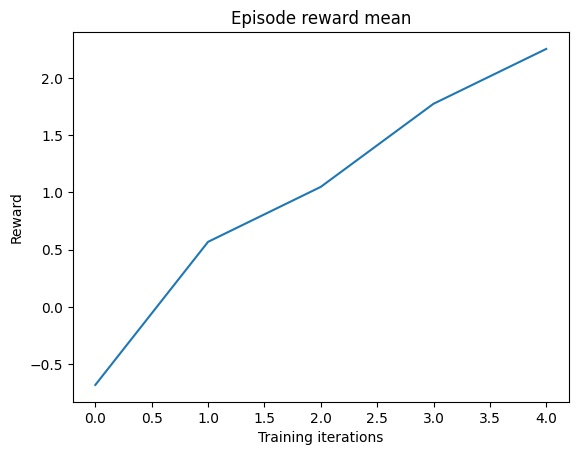

In [19]:
plt.plot(episode_reward_mean_list)
plt.xlabel("Training iterations")
plt.ylabel("Reward")
plt.title("Episode reward mean")
plt.show()

## Summary

This is Multi-Agent PPO (MAPPO).
Centralized training.
Decentralized execution.
Stable and effective for cooperation.


## Summary

This is Multi-Agent PPO (MAPPO).
Centralized training.
Decentralized execution.
Stable and effective for cooperation.


## Summary

This is Multi-Agent PPO (MAPPO).
Centralized training.
Decentralized execution.
Stable and effective for cooperation.


/usr/local/lib/python3.12/dist-packages/imageio/plugins/pillow.py:410: DeprecationWarning: The keyword `fps` is no longer supported. Use `duration`(in ms) instead, e.g. `fps=50` == `duration=20` (1000 * 1/50).
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


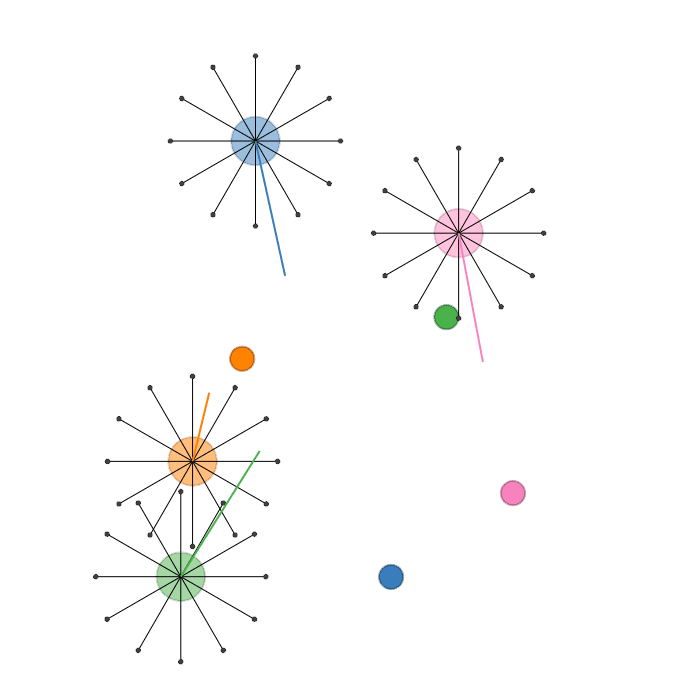

In [20]:
# uncomment if render fails ---
!pip -q install pyvirtualdisplay
from pyvirtualdisplay import Display
Display(visible=0, size=(1400, 900)).start()

import numpy as np
import torch
import imageio
from IPython.display import Image, display

# Create a single VMAS env for rendering (keep scenario & agent count consistent with training)
render_env = VmasEnv(
    scenario=scenario_name,
    num_envs=1,
    device=device,
    continuous_actions=True,
    max_steps=max_steps,
    seed=0,
    n_agents=n_agents,
)

# Rollout one episode using the trained policy
td = render_env.reset()
frames = []

policy.eval()
with torch.no_grad():
    for _ in range(max_steps):
        td = policy(td)          # adds action at env.action_key
        td = render_env.step(td)
        td = td["next"]          # advance to next state

        # VMAS render: returns an RGB array (H, W, 3)
        frame = render_env.render(mode="rgb_array")
        if isinstance(frame, torch.Tensor):
            frame = frame.cpu().numpy()
        frames.append(frame)

render_env.close()

# Save and display
gif_path = "vmas_rollout.gif"
imageio.mimsave(gif_path, frames, fps=15)
display(Image(filename=gif_path))

## Summary:
- This notebook implements Multi-Agent Proximal Policy Optimization (MAPPO) using PyTorch and TorchRL in the VMAS simulator. The goal is to train multiple cooperative agents in a continuous control navigation task, where each agent must learn to act based only on its own local observation while collectively maximizing cumulative reward.

- We begin by formally modeling the problem as a multi-agent Markov Decision Process (stochastic game). Each timestep consists of a joint observation, joint action, reward, and transition. However, although the environment is multi-agent, execution is decentralized — meaning each agent makes decisions independently using its own observation. This mirrors real-world systems such as coordinated drones, robotic teams, or distributed sensors, where centralized execution is often infeasible.

- The environment used is VMAS (Vectorized Multi-Agent Simulator), which allows us to run multiple parallel environments efficiently, even on a GPU. This parallelization significantly improves data collection speed, which is critical for policy-gradient methods like PPO that require fresh on-policy data at every iteration.

- Next, we define the policy network using a MultiAgentMLP. This network maps each agent’s observation to the parameters of a Gaussian action distribution. The key design choice here is parameter sharing — all agents use the same neural network weights. This improves sample efficiency and stabilizes learning because agents are often symmetric in cooperative tasks. Although parameters are shared, the execution remains decentralized since each agent feeds its own observation into the network.

- To train the policy, we use Proximal Policy Optimization (PPO). PPO is a policy-gradient method derived from the policy gradient theorem. It updates the policy by increasing the probability of advantageous actions. However, naïve policy gradients can cause unstable updates. PPO addresses this by introducing a clipped objective, which prevents the new policy from deviating too far from the previous one. This makes learning far more stable, especially in multi-agent settings.

- We also train a value function (critic) alongside the policy. The critic estimates expected future returns and is trained using a regression loss. The value estimates are used to compute advantages, which tell us how much better an action is compared to average behavior at that state.

- To further stabilize training, we use Generalized Advantage Estimation (GAE). GAE balances bias and variance in advantage computation, which reduces noise in gradient updates. Additionally, an entropy bonus is included to encourage exploration and prevent premature convergence.

- The training loop operates in iterations. In each iteration:
We collect a batch of experience from parallel environments.
Compute returns and advantages.Perform multiple epochs of mini-batch optimization using PPO's clipped objective. Repeat the process for several iterations.

- Finally, reward accumulation is handled via a transformation wrapper so we can track episode-level performance across agents. This allows us to visualize training progress and verify convergence.

Conceptually, the notebook walks through this progression:

Bellman Equation
→ Value Function
→ Advantage Estimation
→ Policy Gradient
→ PPO Clipping
→ Multi-Agent Extension (MAPPO)

By the end, we have a full cooperative multi-agent learning RL system that demonstrates stable training, decentralized execution, shared representation learning, and scalable data collection.